___________________________________
# Medical Insurance Cost Prediction

## Tools Used
- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook

## Machine Learning Models
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

## Project Objective

The objective of this project is to analyze raw medical insurance data, perform data cleaning, feature engineering, exploratory data analysis (EDA), statistical analysis, and build machine learning regression models to predict insurance charges. Multiple regression models are compared to identify the best-performing algorithm and understand the key factors influencing medical insurance costs.
___________________________________

___________________________________

## Initial Observation
- The dataset contains raw medical insurance customer information.
- The target variable is Charges.
- Charges represent the medical insurance cost of a customer.
- The dataset includes demographic and health-related features such as age, gender, BMI, smoking status, region, and number of children.
- The goal is to predict insurance charges and identify the major factors affecting medical insurance costs.
___________________________________

___________________________________
## SECTION 1 — Import Libraries
* Importing required Python libraries for data analysis and visualization.
___________________________________

In [1]:
# Data Handling

import numpy as np
import pandas as pd

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

___________________________________
## SECTION 2 — Load Dataset & Dataset Overview
* Loading the medical insurance dataset into pandas DataFrame.
* Understanding dataset structure using shape, columns, data types, and statistical summary.
___________________________________

In [2]:
# Load Dataset

df = pd.read_csv('../Dataset/Medical Insurance Raw Data.csv')

In [3]:
# Display Dataset

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Dataset Shape

df.shape

(1338, 7)

In [5]:
# Column Names

df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [6]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
# Statistical Summary

df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


___________________________________
## SECTION 3 — Data Quality Check
* Checking missing values and duplicate records in the dataset.
___________________________________

In [8]:
# Check Missing Values

df.isnull().head(10)

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
# Check Duplicate Records

df.duplicated().sum()

np.int64(1)

In [11]:
# Remove Duplicate Records

df.drop_duplicates(inplace=True)

In [12]:
# Verify Duplicate Removal

df.duplicated().sum()

np.int64(0)

In [13]:
# Dataset Shape

df.shape

(1337, 7)

In [14]:
# Verify Data Types

df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

___________________________________
# SECTION 4 — Feature Engineering
Creating new meaningful features from existing data to improve business analysis and help machine learning models understand customer patterns better.
___________________________________

In [15]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


___________________________________
## Create Age Group
Grouping customers into different age categories to analyze insurance charges based on life stages.
___________________________________

In [16]:
def Age_Group(age):
    if age < 30:
        return 'Young'
    elif age < 50:
        return 'Adult'
    else:
        return 'Senior'

df['age_group'] = df['age'].apply(Age_Group)

In [17]:
df[['age', 'age_group']].head()

,age,age_group
0,19,Young
1,18,Young
2,28,Young
3,33,Adult
4,32,Adult


___________________________________
## Create BMI Category
Converting continuous BMI values into health-related categories to better understand the impact of body condition on insurance charges.
___________________________________

In [18]:
def BMI_Category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(BMI_Category)

In [19]:
# A new feature age_group & bmi_category has been created.

df[['age', 'age_group', 'bmi', 'bmi_category']].head()

,age,age_group,bmi,bmi_category
0,19,Young,27.900,Overweight
1,18,Young,33.770,Obese
2,28,Young,33.000,Obese
3,33,Adult,22.705,Normal
4,32,Adult,28.880,Overweight


___________________________________
### Check Updated Dataset
Checking the dataset after adding the new engineered features.
___________________________________

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1337 non-null   int64  
 1   sex           1337 non-null   object 
 2   bmi           1337 non-null   float64
 3   children      1337 non-null   int64  
 4   smoker        1337 non-null   object 
 5   region        1337 non-null   object 
 6   charges       1337 non-null   float64
 7   age_group     1337 non-null   object 
 8   bmi_category  1337 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 104.5+ KB


___________________________________
# SECTION 5 — Exploratory Data Analysis (EDA)
* Performing exploratory data analysis to identify patterns, distributions, trends, and relationships in the medical insurance dataset.
___________________________________

___________________________________
### Unique Values Analysis
* #### Unique Values in Categorical Columns
    * Checking unique categories present in categorical columns.
___________________________________

In [21]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [22]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [23]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

___________________________________
## Now Visualization the Data
* ### 1. Smoker Distribution Visualization
    * Visualizing smoker and non-smoker distribution using Seaborn countplot.
___________________________________

In [24]:
df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

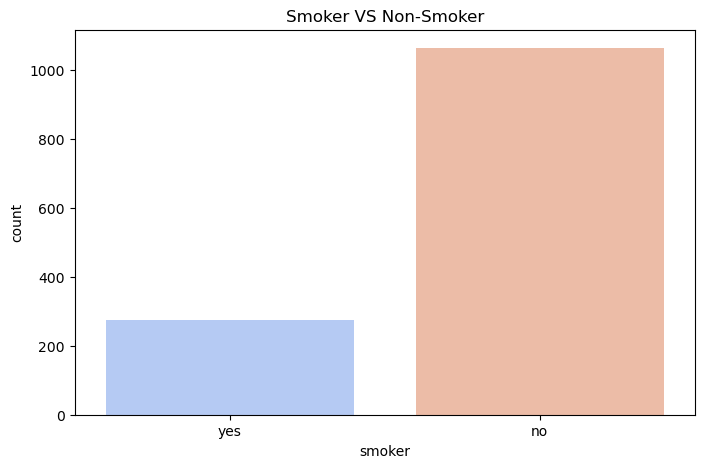

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(x='smoker', data= df, hue= 'smoker', palette='coolwarm')

plt.title('Smoker VS Non-Smoker')
plt.show()

___________________________________
### 2. Gender Distribution Visualization
Visualizing the distribution of male and female patients in the dataset.
___________________________________

In [26]:
df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

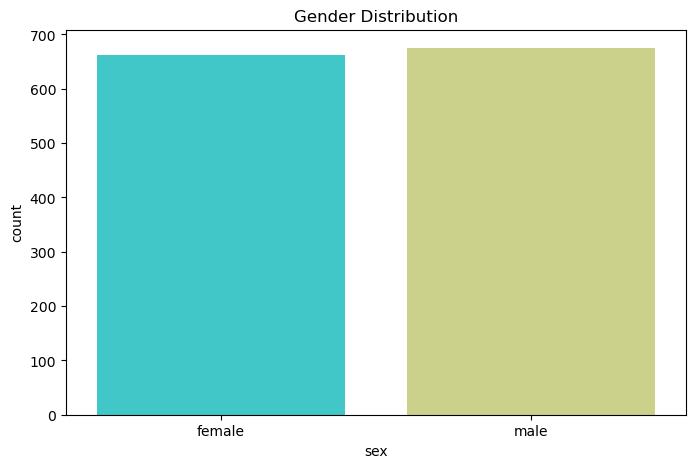

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(x='sex', data= df, hue= 'sex', palette= 'rainbow')

plt.title('Gender Distribution')
plt.show()

___________________________________
### 3. Region Distribution Visualization 
Analyzing patient distribution across different regions.
___________________________________

In [28]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

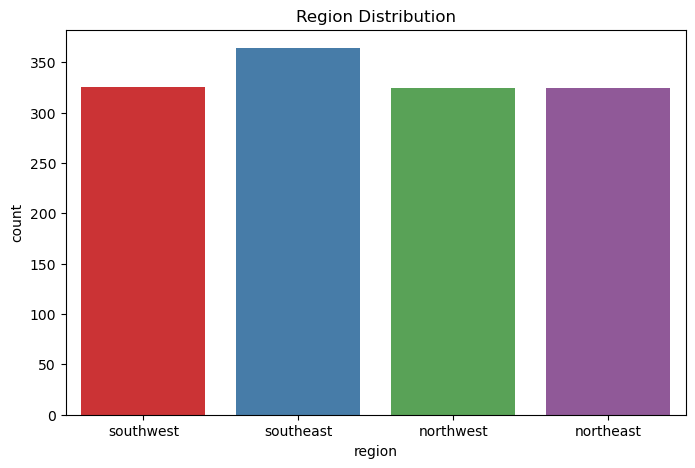

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(x= 'region', data= df, hue= 'region', palette= 'Set1')

plt.title('Region Distribution')
plt.show()

___________________________________
### 4. BMI Distribution
Visualizing the distribution of BMI values using histogram.
___________________________________

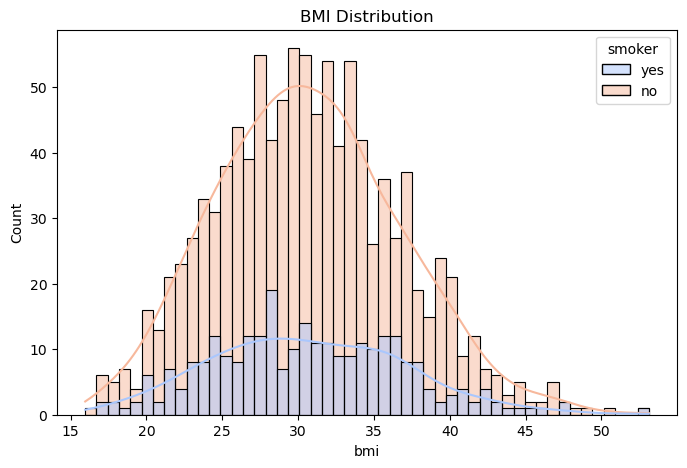

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(x= 'bmi', data= df, bins=50, hue= 'smoker', palette= 'coolwarm', kde=True)

plt.title('BMI Distribution')
plt.show()

___________________________________
### 5. BMI Analysis
Analyzing the relationship between BMI and insurance charges.
___________________________________

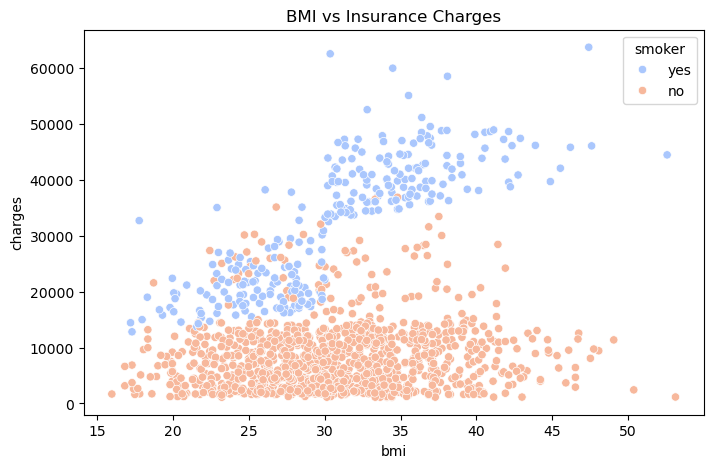

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker', palette='coolwarm')

plt.title('BMI vs Insurance Charges')
plt.show()

___________________________________
### 6. Insurance Charges Distribution
Analyzing the distribution of insurance charges.
___________________________________

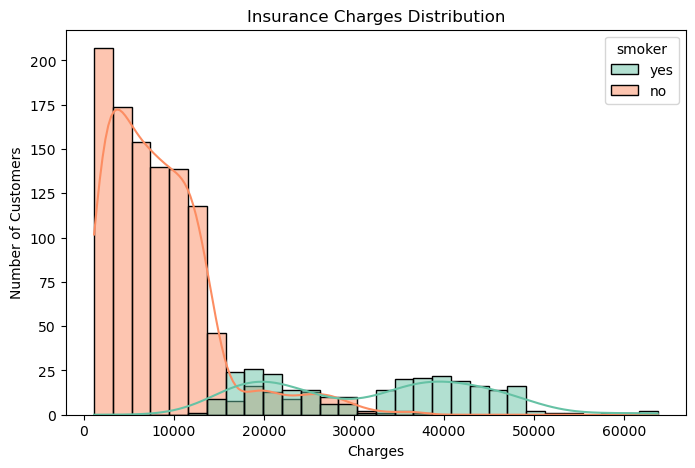

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(x= 'charges', data= df, bins=30, hue= 'smoker', palette= 'Set2', kde= True)

plt.title('Insurance Charges Distribution')
plt.xlabel('Charges')
plt.ylabel('Number of Customers')

plt.show()

___________________________________
### 7. Age vs Insurance Charges
Analyzing the relationship between age and insurance charges.
___________________________________

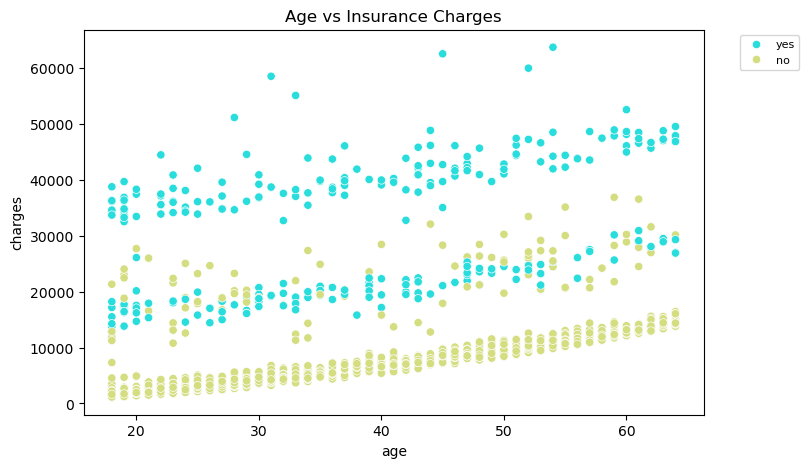

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(x= 'age', y= 'charges', data= df, hue= 'smoker', palette= 'rainbow')

plt.title('Age vs Insurance Charges')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.show()

___________________________________
### 8. Smoker vs Insurance Charges
Analyzing how smoking affects insurance charges.
___________________________________

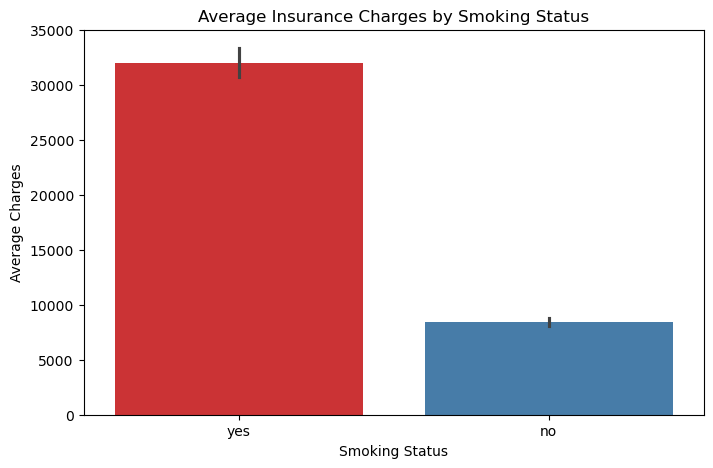

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(x= 'smoker', y= 'charges', data= df, hue= 'smoker', palette= 'Set1')

plt.title('Average Insurance Charges by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Average Charges')

plt.show()

___________________________________
### 9. Gender Analysis
Comparing average insurance charges between male and female customers
___________________________________

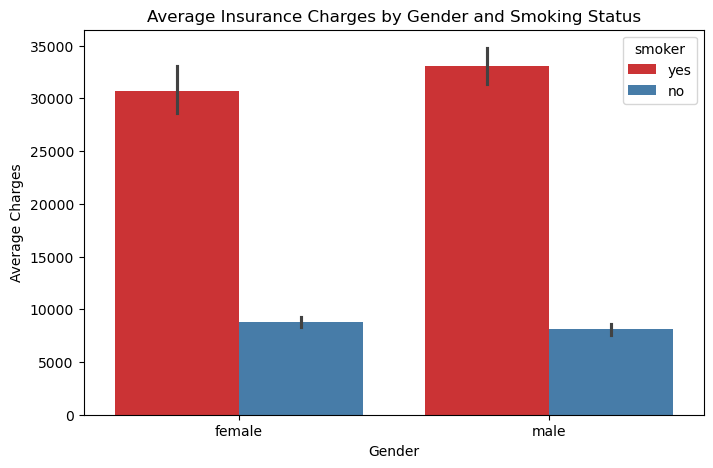

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(x='sex', y='charges', data=df, hue='smoker', palette='Set1')

plt.title('Average Insurance Charges by Gender and Smoking Status')
plt.xlabel('Gender')
plt.ylabel('Average Charges')

plt.show()

___________________________________
### 10. Region Analysis
Comparing insurance charges across different geographical regions.
___________________________________

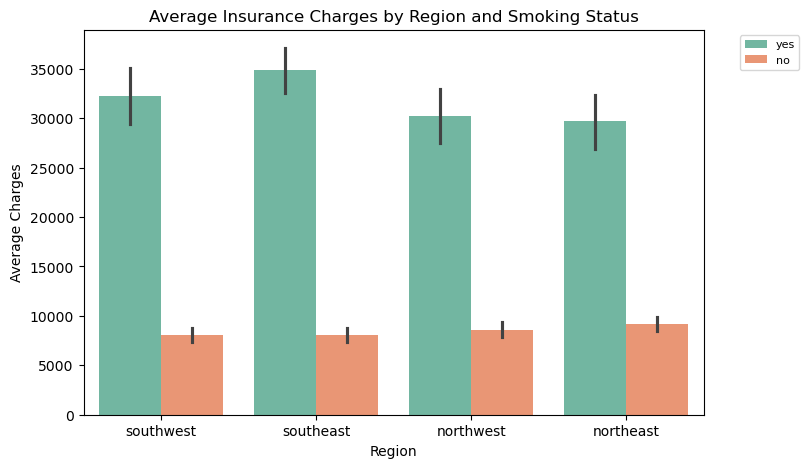

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(x='region', y='charges', data=df, hue='smoker', palette='Set2')

plt.title('Average Insurance Charges by Region and Smoking Status')
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.show()

___________________________________
### 11. Children Analysis
Understanding how the number of children affect insurance charges.
___________________________________

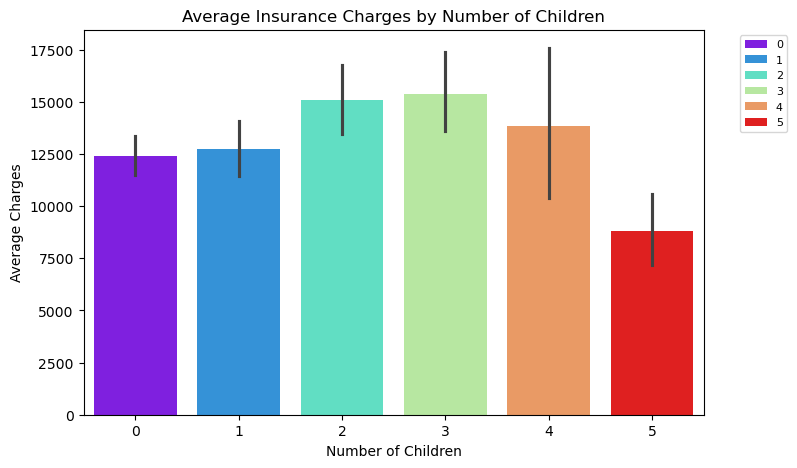

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(x='children',y='charges',data=df, hue= 'children', palette= 'rainbow')

plt.title('Average Insurance Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Average Charges')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.show()

___________________________________
### 12. Age Group Analysis (Feature Engineering)
Analyzing insurance charges across different age categories created during feature engineering.
___________________________________

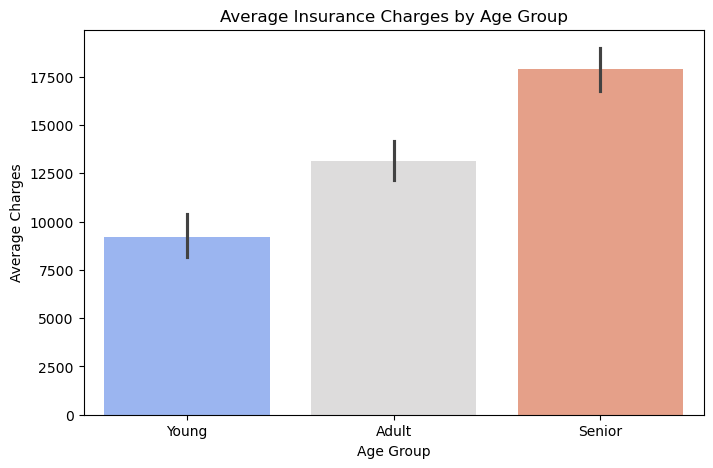

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(x='age_group', y='charges', data=df, hue= 'age_group', palette= 'coolwarm')

plt.title('Average Insurance Charges by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Charges')

plt.show()

___________________________________
### 13. BMI Category Analysis (Feature Engineering)
Comparing insurance charges across different BMI categories.
___________________________________

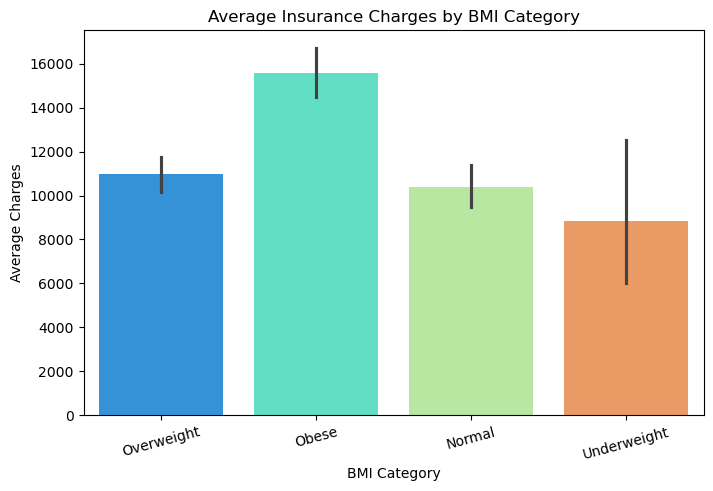

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(x='bmi_category', y='charges', data=df, hue= 'bmi_category', palette= 'rainbow')

plt.title('Average Insurance Charges by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Average Charges')
plt.xticks(rotation= 15)

plt.show()

___________________________________
## 14. Correlation Heatmap
Visualizing relationships between numerical variables using correlation heatmap.
___________________________________

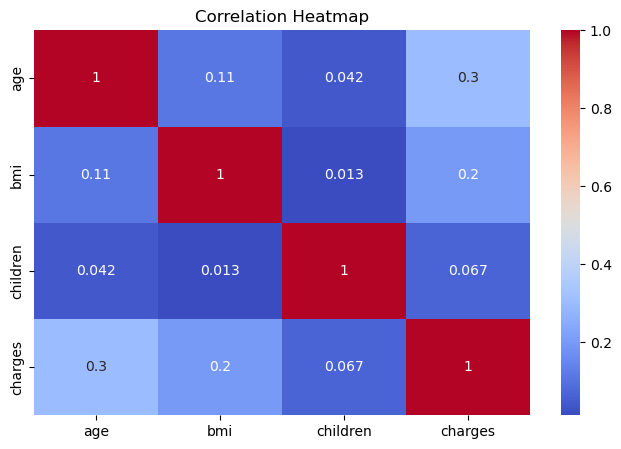

In [40]:
plt.figure(figsize=(8,5))

correlation = df[['age','bmi','children','charges']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

___________________________________ 
# SECTION 6  —  NumPy Statistical Analysis
Performing statistical analysis using NumPy to understand the numerical characteristics of medical insurance data.
___________________________________

___________________________________
## Mean (Average) Analysis
Calculating the average values of numerical features using NumPy.

**Question:-** What are the average values of age, BMI, children, and insurance charges?
___________________________________

In [41]:
import numpy as np

# Calculate Mean
mean_age = round(np.mean(df['age']),2)
mean_bmi = round(np.mean(df['bmi']),2)
mean_children = round(np.mean(df['children']),2)
mean_charges = round(np.mean(df['charges']),2)

print("Average Age:", mean_age)
print("Average BMI:", mean_bmi)
print("Average Number of Children:", mean_children)
print("Average Insurance Charges:", mean_charges)

Average Age: 39.22
Average BMI: 30.66
Average Number of Children: 1.1
Average Insurance Charges: 13279.12


___________________________________
## Median Analysis
Calculating the median values of numerical features using NumPy to understand the central position of the data.

**Question:-** What are the middle values of age, BMI, number of children, and insurance charges?
___________________________________

In [42]:
# Calculate Median

median_age = np.median(df['age'])
median_bmi = np.median(df['bmi'])
median_children = np.median(df['children'])
median_charges = np.median(df['charges'])

print("Median Age:", median_age)
print("Median BMI:", median_bmi)
print("Median Number of Children:", median_children)
print("Median Insurance Charges:", median_charges)

Median Age: 39.0
Median BMI: 30.4
Median Number of Children: 1.0
Median Insurance Charges: 9386.1613


___________________________________
## Standard Deviation Analysis
Calculating the standard deviation of numerical features using NumPy to understand the spread and variability of the data.

**Question:-** How much do age, BMI, number of children, and insurance charges vary from their average values?
___________________________________

In [43]:
# Calculate Standard Deviation

std_age = round(np.std(df['age']),2)
std_bmi = round(np.std(df['bmi']),2)
std_children = round(np.std(df['children']),2)
std_charges = round(np.std(df['charges']),2)

print("Standard Deviation of Age:", std_age)
print("Standard Deviation of BMI:", std_bmi)
print("Standard Deviation of Children:", std_children)
print("Standard Deviation of Insurance Charges:", std_charges)

Standard Deviation of Age: 14.04
Standard Deviation of BMI: 6.1
Standard Deviation of Children: 1.21
Standard Deviation of Insurance Charges: 12105.83


___________________________________
## Minimum and Maximum Analysis
Finding the minimum and maximum values of numerical features using NumPy to understand the range of the data.

**Question:-** What are the lowest and highest values of age, BMI, number of children, and insurance charges?
___________________________________

In [44]:
# Calculate Minimum Values

min_age = np.min(df['age'])
min_bmi = np.min(df['bmi'])
min_children = np.min(df['children'])
min_charges = round(np.min(df['charges']),2)

print("Minimum Age:", min_age)
print("Minimum BMI:", min_bmi)
print("Minimum Number of Children:", min_children)
print("Minimum Insurance Charges:", min_charges)

Minimum Age: 18
Minimum BMI: 15.96
Minimum Number of Children: 0
Minimum Insurance Charges: 1121.87


In [45]:
# Calculate Maximum Values

max_age = np.max(df['age'])
max_bmi = np.max(df['bmi'])
max_children = np.max(df['children'])
max_charges = round(np.max(df['charges']),2)

print("Maximum Age:", max_age)
print("Maximum BMI:", max_bmi)
print("Maximum Number of Children:", max_children)
print("Maximum Insurance Charges:", max_charges)

Maximum Age: 64
Maximum BMI: 53.13
Maximum Number of Children: 5
Maximum Insurance Charges: 63770.43


___________________________________
## Percentile Analysis
Calculating percentiles using NumPy to understand the distribution and spread of numerical features.

**Question:-** What are the 25th, 50th, and 75th percentile values of age, BMI, children, and insurance charges?
___________________________________

In [46]:
np.percentile(df['age'], [25,50,75])

array([27., 39., 51.])

In [47]:
np.percentile(df['bmi'], [25,50,75])

array([26.29, 30.4 , 34.7 ])

In [48]:
np.percentile(df['children'], [25,50,75])

array([0., 1., 2.])

In [49]:
np.percentile(df['charges'], [25,50,75]).round(2)

array([ 4746.34,  9386.16, 16657.72])

___________________________________
# SECTION 7 — Data Preprocessing 
Preparing the dataset for machine learning by converting categorical variables into numerical format, selecting input features and target variable, splitting data into training and testing sets, and applying feature scaling.
___________________________________

In [50]:
df.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,Young,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Young,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Young,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Adult,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Adult,Overweight


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1337 non-null   int64  
 1   sex           1337 non-null   object 
 2   bmi           1337 non-null   float64
 3   children      1337 non-null   int64  
 4   smoker        1337 non-null   object 
 5   region        1337 non-null   object 
 6   charges       1337 non-null   float64
 7   age_group     1337 non-null   object 
 8   bmi_category  1337 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 104.5+ KB


___________________________________
## Encode Categorical Variables
* Converting categorical columns into numerical format using one-hot encoding.
* Because machine learning models cannot understand text. Therefore it will have to be encoded.
___________________________________

In [52]:
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [53]:
# Displaying dataset after categorical encoding.

df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age_group_Senior,age_group_Young,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
0,19,27.900,0,16884.92400,0,1,0,0,1,0,1,0,1,0
1,18,33.770,1,1725.55230,1,0,0,1,0,0,1,1,0,0
2,28,33.000,3,4449.46200,1,0,0,1,0,0,1,1,0,0
3,33,22.705,0,21984.47061,1,0,1,0,0,0,0,0,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0,0,0,0,1,0


In [54]:
# Dataset Shape

df.shape

(1337, 14)

In [55]:
# Dataset Information After Encode Categorical Variables 

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1337 non-null   int64  
 1   bmi                       1337 non-null   float64
 2   children                  1337 non-null   int64  
 3   charges                   1337 non-null   float64
 4   sex_male                  1337 non-null   int64  
 5   smoker_yes                1337 non-null   int64  
 6   region_northwest          1337 non-null   int64  
 7   region_southeast          1337 non-null   int64  
 8   region_southwest          1337 non-null   int64  
 9   age_group_Senior          1337 non-null   int64  
 10  age_group_Young           1337 non-null   int64  
 11  bmi_category_Obese        1337 non-null   int64  
 12  bmi_category_Overweight   1337 non-null   int64  
 13  bmi_category_Underweight  1337 non-null   int64  
dtypes: float64(2)

___________________________________
## Feature and Target Variables Split
Separating input features and the target variable for machine learning training.
___________________________________

In [56]:
x = df.drop('charges', axis=1)

y = df['charges']

print(x.shape)
print(y.shape)

(1337, 13)
(1337,)


In [57]:
# Checking feature variables.

x.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age_group_Senior,age_group_Young,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
0,19,27.900,0,0,1,0,0,1,0,1,0,1,0
1,18,33.770,1,1,0,0,1,0,0,1,1,0,0
2,28,33.000,3,1,0,0,1,0,0,1,1,0,0
3,33,22.705,0,1,0,1,0,0,0,0,0,0,0
4,32,28.880,0,1,0,1,0,0,0,0,0,1,0


In [58]:
# Checking target variable.

y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

___________________________________
## Train Test Split
Dividing the dataset into training and testing sets to evaluate the model's performance on unseen data.
___________________________________

In [59]:
# import train_test_split

from sklearn.model_selection import train_test_split

In [60]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

___________________________________
## Training and Testing Data Shapes
Checking the dimensions of training and testing datasets.
___________________________________

In [61]:
x_train.shape

(1069, 13)

In [62]:
x_test.shape

(268, 13)

In [63]:
y_train.shape

(1069,)

In [64]:
y_test.shape

(268,)

___________________________________
## Standardize the Variables
* **Standardize the Variables means:-**  Bringing every feature on the same scale. So that the model does not get confused by small and big numbers.
* Standardizing the numerical features by converting them into a common scale with a **mean of 0 and a standard deviation of 1.** This helps machine learning models process features with different ranges more effectively.
___________________________________

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

___________________________________
# SECTION 8 — Machine Learning Model
Building and training multiple machine learning regression models to predict medical insurance charges and analyze which algorithm provides the most accurate predictions.
___________________________________

___________________________________
# 1: — Linear Regression Model

Training a Linear Regression model to understand the relationship between customer features and insurance charges and to predict future medical insurance costs.
___________________________________

___________________________________
### Import Linear Regression Model
Importing Linear Regression algorithm from scikit-learn.
___________________________________

In [66]:
from sklearn.linear_model import LinearRegression

___________________________________
## Create Linear Regression Model
Creating the Linear Regression model object.
___________________________________

In [67]:
model_lr = LinearRegression()

___________________________________
## Train the Model
Training the Linear Regression model using training data.
___________________________________

In [68]:
model_lr.fit(x_train, y_train)

LinearRegression()

___________________________________
## Make Predictions
Predicting insurance charges using the trained model.
___________________________________

In [69]:
y_pred_lr = model_lr.predict(x_test)

___________________________________
## Predicted Values
Displaying predicted insurance charges.
___________________________________

In [70]:
y_pred_lr[:5]

array([ 7197.6772075 ,  6689.58620848, 15368.07026038, 31524.78441488,
        7834.26785282])

___________________________________
## Linear Regression Model Evaluation
* Evaluating the performance of the Linear Regression model using regression evaluation metrics.
___________________________________

___________________________________
## Import Evaluation Metrics
Importing model evaluation metrics from scikit-learn.
___________________________________

In [71]:
from sklearn import metrics

___________________________________
### Mean Absolute Error (MAE)
Calculating average prediction error.
___________________________________

In [72]:
mae = round(metrics.mean_absolute_error(y_test, y_pred_lr),2)

mae

4407.45

___________________________________
### Mean Squared Error (MSE)
Calculating squared prediction error.
___________________________________

In [73]:
mse = round(metrics.mean_squared_error(y_test, y_pred_lr),2)

mse

36805654.26

___________________________________
### Root Mean Squared Error (RMSE)
Calculating root mean squared error for model evaluation.
___________________________________

In [74]:
rmse = round(np.sqrt(metrics.mean_squared_error(y_test, y_pred_lr)),2)

rmse

np.float64(6066.77)

___________________________________
### R² Score
Measuring the accuracy of the Linear Regression model.
___________________________________

In [75]:
r2 = metrics.r2_score(y_test, y_pred_lr)

r2

0.7997037297474727

In [76]:
from sklearn import metrics

mae = round(metrics.mean_absolute_error(y_test, y_pred_lr),2)
mse = round(metrics.mean_squared_error(y_test, y_pred_lr),2)
rmse = round(np.sqrt(metrics.mean_squared_error(y_test, y_pred_lr)),2)
r2 = metrics.r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4407.45
MSE: 36805654.26
RMSE: 6066.77
R² Score: 0.7997037297474727


___________________________________

# 2: —  Decision Tree Regressor
Training a Decision Tree Regressor model to capture non-linear relationships between customer characteristics and insurance charges.
___________________________________

In [77]:
# Import Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

In [78]:
# Create Model

model_dt = DecisionTreeRegressor(random_state=42)

In [79]:
# Train the Model

model_dt.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [80]:
# Make Predictions

y_pred_dt = model_dt.predict(x_test)

___________________________________
## Decision Tree Model Evaluation
Evaluating the Decision Tree model using regression evaluation metrics to measure prediction errors and overall performance.
___________________________________

In [81]:
dt_mae = round(metrics.mean_absolute_error(y_test, y_pred_dt),2)
dt_mse = round(metrics.mean_squared_error(y_test, y_pred_dt),2)
dt_rmse = round(np.sqrt(metrics.mean_squared_error(y_test, y_pred_dt)),2)
dt_r2 = metrics.r2_score(y_test, y_pred_dt)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree MSE:", dt_mse)
print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R² Score", dt_r2) 

Decision Tree MAE: 2572.31
Decision Tree MSE: 31966133.33
Decision Tree RMSE: 5653.86
Decision Tree R² Score 0.826040389493593


___________________________________
# 3: — Random Forest Regressor
Training a Random Forest Regressor model by combining multiple decision trees to improve prediction accuracy and reduce overfitting.
___________________________________

In [82]:
# Import Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

In [83]:
# Create Model

model_rf = RandomForestRegressor(n_estimators= 100, random_state= 42)

In [84]:
# Train the Model

model_rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [85]:
# Make Predictions

y_pred_rf = model_rf.predict(x_test)

___________________________________
## Random Forest Model Evaluation
Evaluating the Random Forest model using regression metrics to measure prediction errors and prediction accuracy.
___________________________________

In [86]:
rf_mae = round(metrics.mean_absolute_error(y_test, y_pred_rf),2)
rf_mse = round(metrics.mean_squared_error(y_test, y_pred_rf),2)
rf_rmse = round(np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf)),2)
rf_r2 = metrics.r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R² Score:",  rf_r2)

Random Forest MAE: 2646.85
Random Forest MSE: 21898028.84
Random Forest RMSE: 4679.53
Random Forest R² Score: 0.8808309867023241


___________________________________
## Compare Actual vs Predicted Values
Comparing actual and predicted insurance charges.
___________________________________

### Create Comparison Table

In [87]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf
})

results.head()

,Actual,Predicted
900,8688.85885,8855.318635
1064,5708.86700,10358.637952
1256,11436.73815,12046.084893
298,38746.35510,42126.534719
237,4463.20510,6770.999339


___________________________________
## Actual vs Predicted Charges Visualization
Comparing actual insurance charges with predicted charges generated by the Random Forest model.
___________________________________

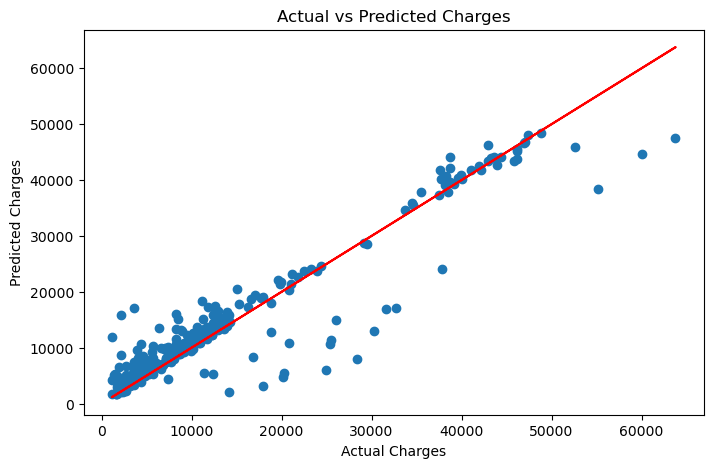

In [88]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf)
plt.plot(y_test, y_test, color= 'red')

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges')

plt.show()

___________________________________

# SECTION 9 — Model Comparison
Comparing the performance of multiple machine learning models using evaluation metrics to identify the most suitable model for predicting medical insurance charges.
___________________________________

### Create Model Comparison Table

In [89]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [mae, dt_mae, rf_mae],
    'MSE': [mse, dt_mse, rf_mse],
    'RMSE': [rmse, dt_rmse, rf_rmse],
    'R² Score': [r2, dt_r2, rf_r2]
})

comparison = comparison.round(2)

comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,4407.45,36805654.26,6066.77,0.80
1,Decision Tree,2572.31,31966133.33,5653.86,0.83
2,Random Forest,2646.85,21898028.84,4679.53,0.88


___________________________________
## Model Performance Comparison Visualization
Visual comparison of regression model performance using R² Score.
___________________________________

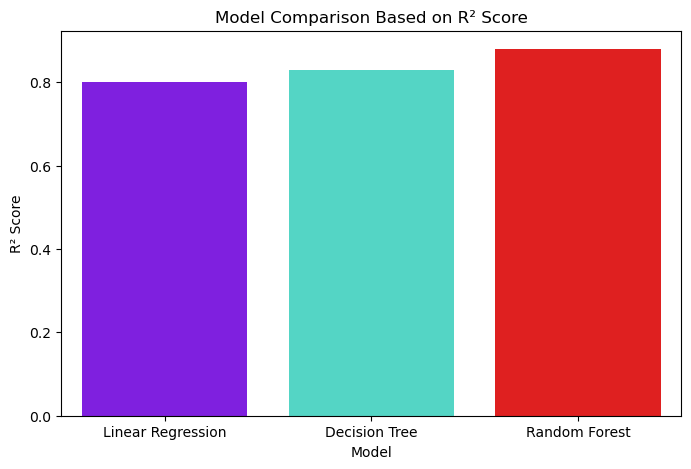

In [90]:
plt.figure(figsize=(8,5))

sns.barplot(x= 'Model', y= 'R² Score', data= comparison, 
            hue= 'R² Score', palette= 'rainbow', legend= False)

plt.title('Model Comparison Based on R² Score')

plt.show()

___________________________________
## Best Performing Model
Identifying the best regression model based on performance metrics.

* **Insight**
    * The model comparison showed that Random Forest Regressor achieved the highest R² Score and lowest prediction error among all models, making it the most suitable algorithm for predicting medical insurance charges.
___________________________________


___________________________________
# SECTION 10 — Model Interpretation
Understanding how different features influence insurance charges by interpreting machine learning models and identifying the most important factors affecting predictions.
___________________________________

___________________________________
## Linear Regression Coefficients
Analyzing the coefficients of the Linear Regression model to understand the direction and strength of the relationship between input features and insurance charges.
___________________________________

In [91]:
model_lr

LinearRegression()

#### Create Coefficient Table

In [92]:
coef_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": model_lr.coef_
})

coef_df.sort_values(
    by="Coefficient",
    ascending=False)

,Feature,Coefficient
4,smoker_yes,23094.306545
10,bmi_category_Obese,3447.807429
9,age_group_Young,2128.158892
8,age_group_Senior,1343.436698
2,children,722.491455
0,age,267.801887
11,bmi_category_Overweight,242.015960
1,bmi,75.643890
3,sex_male,-87.208396
5,region_northwest,-460.318371


___________________________________
## Linear Regression Coefficients Visualization
Visualizing the Linear Regression coefficients to understand which features increase or decrease predicted medical insurance charges.
___________________________________

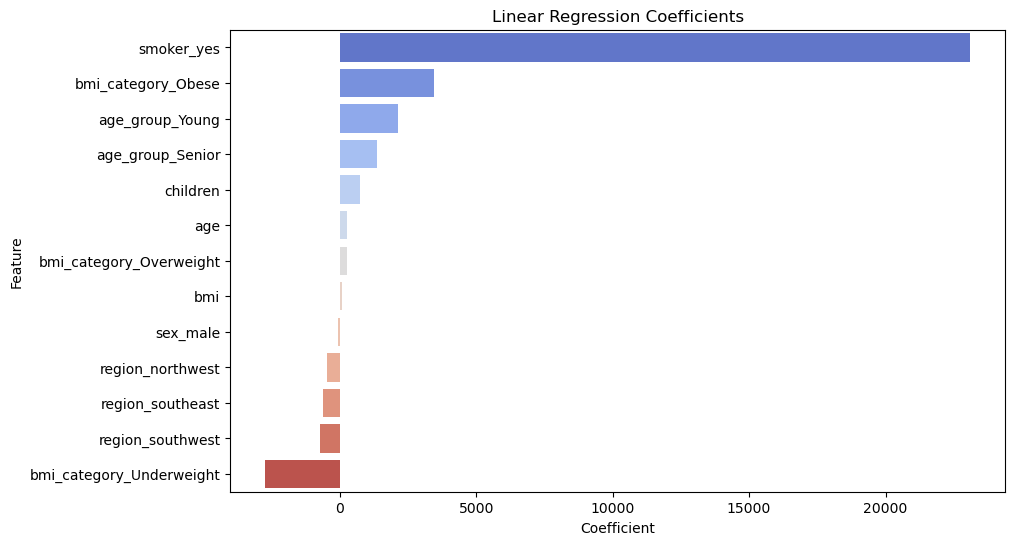

In [93]:
plt.figure(figsize=(10,6))

sns.barplot(x= 'Coefficient', y='Feature', 
            data= coef_df.sort_values(by="Coefficient", ascending=False),  
            hue= 'Feature', palette="coolwarm")

plt.title("Linear Regression Coefficients")

plt.show()

___________________________________
# Random Forest Feature Importance
Analyzing the importance scores assigned by Random Forest to identify which features contribute the most to insurance charge prediction.
___________________________________

In [94]:
model_rf

RandomForestRegressor(random_state=42)

#### Create Coefficient Table

In [95]:
importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": model_rf.feature_importances_
})

importance_df.sort_values(
    by="Importance",
    ascending=False)

,Feature,Importance
4,smoker_yes,0.600777
1,bmi,0.186778
0,age,0.134103
10,bmi_category_Obese,0.026236
2,children,0.022645
5,region_northwest,0.006793
3,sex_male,0.006638
6,region_southeast,0.005847
7,region_southwest,0.004584
11,bmi_category_Overweight,0.003056


___________________________________
## Random Forest Feature Importance Visualization
Visualizing Random Forest feature importance scores to identify the most influential factors affecting insurance charge predictions.
___________________________________

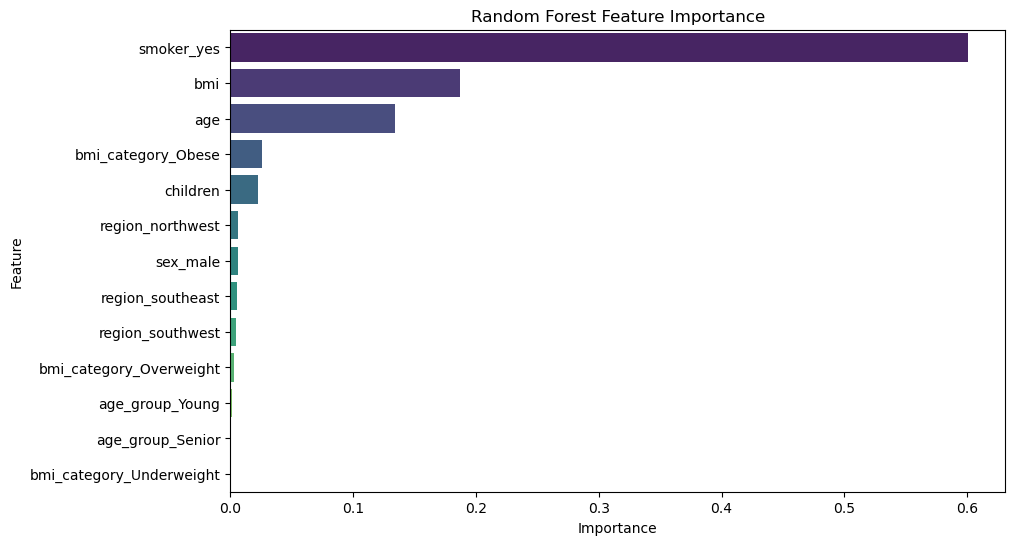

In [96]:
plt.figure(figsize=(10, 6))

sns.barplot(x="Importance", y="Feature",
    data= importance_df.sort_values(by="Importance", ascending=False),
    hue = 'Feature', palette="viridis")

plt.title("Random Forest Feature Importance")

plt.show()

___________________________________
# SECTION 11 — Business Insights
Generating meaningful business insights from data analysis and machine learning results to understand the key factors affecting medical insurance costs and support better decision-making.
___________________________________

## Business Insights
___________________________________
1. **Smoking Has the Highest Impact on Insurance Charges**
    * Smokers have significantly higher insurance costs.
    * Both Linear Regression and Random Forest identified smoking as the strongest factor affecting charges.
___________________________________
2. **Obesity and High BMI Increase Insurance Risk**
    * Customers with higher BMI, especially obese individuals, tend to have higher insurance expenses.
    * BMI was the second most important factor in Random Forest analysis.
___________________________________
3. **Age Influences Insurance Costs**
    * Age plays an important role in determining insurance charges.
    * Older customers generally require more healthcare attention, leading to increased costs.
___________________________________
4. **Gender and Region Have Limited Impact**
    * Gender and geographical regions contributed less to insurance cost prediction compared with health-related factors.
___________________________________
5. **Machine Learning Can Improve Cost Prediction**
    * The Random Forest model achieved the best performance with an R² Score of 0.88, showing strong ability to estimate insurance charges.
    * Such models can help insurance companies make more accurate pricing decisions.
___________________________________

___________________________________
### Mini Insight 
The analysis revealed that smoking, BMI, and age are the major drivers of medical insurance costs. Machine learning models, especially Random Forest, can effectively predict insurance charges and help insurance providers make more accurate risk and pricing decisions.
___________________________________

___________________________________
# SECTION 12 — Final Conclusion
Summarizing the overall project findings, machine learning performance, and the key factors influencing medical insurance charges.
___________________________________

## Final Conclusion
___________________________________
This Medical Insurance Cost Prediction project started with raw customer data and transformed it into meaningful insights using data analysis and machine learning techniques.

Data quality checks were performed to ensure the dataset was clean and reliable. Feature engineering was applied by creating Age Groups and BMI Categories, which helped in better understanding customer characteristics.

Exploratory Data Analysis revealed that factors such as smoking status, BMI, and age have a strong relationship with medical insurance charges. Statistical analysis using NumPy further helped in understanding the distribution and variation of customer characteristics and insurance costs.

* **Multiple machine learning regression models were trained and evaluated:**
    * Linear Regression achieved an R² Score of approximately 0.80.
    * Decision Tree Regressor improved the prediction performance with an R² Score of approximately 0.83.
    * Random Forest Regressor achieved the best overall performance with an R² Score of approximately 0.88 and the lowest RMSE value.

Model interpretation confirmed that smoking status was the most influential factor affecting insurance charges, followed by BMI and age. Features such as gender and region had a comparatively smaller impact on the prediction.

Overall, the Random Forest model proved to be the most suitable algorithm for predicting medical insurance charges. This project demonstrates a complete end-to-end machine learning workflow, including raw data processing, feature engineering, exploratory data analysis, statistical analysis, preprocessing, model building, evaluation, interpretation, and business insight generation.
___________________________________

___________________________________
## Final Insight
The project successfully predicted medical insurance charges using machine learning techniques. Among all models, Random Forest Regressor provided the most accurate and reliable predictions. The analysis highlighted that smoking habits, BMI, and age are the primary factors influencing medical insurance costs.
___________________________________